In [3]:
import sys
sys.path.insert(0, ".")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from db import load_transactions

# Dark plot style to match the dashboard
plt.style.use("dark_background")
plt.rcParams.update({
    "axes.facecolor":   "#111710",
    "figure.facecolor": "#0a0f0c",
    "axes.edgecolor":   "#1e2b1e",
    "text.color":       "#d4e8d4",
    "axes.labelcolor":  "#5a7a5a",
    "xtick.color":      "#5a7a5a",
    "ytick.color":      "#5a7a5a",
    "grid.color":       "#1e2b1e",
    "axes.grid":        True,
})

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
df = load_transactions(months=24)

print(f"Transactions loaded: {len(df):,}")
print(f"Date range:  {df.date.min().date()} to {df.date.max().date()}")
print(f"Total spend: ${df.amount.sum():,.2f}")
print()
df.head(10)

Transactions loaded: 193
Date range:  2026-01-09 to 2026-04-08
Total spend: $23,456.88



C:\Users\kpaoi\Personal Finance Dashboard\analytics\.\db.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(sql, conn, params=(months,))


,id,date,amount,name,clean_name,merchant_name,category_primary,category_detailed,pending,account_id,month,year
0,cmnrrqq43000fp40pxk92nxbt,2026-04-08,35.05,PURCHASE AUTHORIZED ON 04/06 Amazon.com*BC9SN2...,Amazon,Amazon,GENERAL_MERCHANDISE,GENERAL_MERCHANDISE_ONLINE_MARKETPLACES,False,cmnrrqlrx0003p40ptgdu3hzg,2026-04,2026
1,cmnrrqq18000bp40pxx8bfrdo,2026-04-08,16.95,PURCHASE AUTHORIZED ON 04/07 AMAZON MKTPL*BC94...,Amazon,Amazon,GENERAL_MERCHANDISE,GENERAL_MERCHANDISE_ONLINE_MARKETPLACES,False,cmnrrqlrx0003p40ptgdu3hzg,2026-04,2026
2,cmnrrqq5j000hp40prszndqxw,2026-04-08,20.76,PetSmart,Petsmart,PetSmart,GENERAL_MERCHANDISE,GENERAL_MERCHANDISE_PET_SUPPLIES,False,cmnrrqlrx0003p40ptgdu3hzg,2026-04,2026
3,cmnrrqq2m000dp40ps5hti328,2026-04-08,539.54,PURCHASE AUTHORIZED ON 04/07 AMAZON MKTPL*BC6F...,Amazon,Amazon,GENERAL_MERCHANDISE,GENERAL_MERCHANDISE_ONLINE_MARKETPLACES,False,cmnrrqlrx0003p40ptgdu3hzg,2026-04,2026
4,cmnrrqsdn003lp40pe4hutmkl,2026-04-07,79.90,SPRINTAX NR TAX SPRINTAX.COM,Sprintax,Sprintax,GENERAL_SERVICES,GENERAL_SERVICES_ACCOUNTING_AND_FINANCIAL_PLAN...,False,cmnrrqlu10007p40poycjf4ah,2026-04,2026
5,cmnrrqsc9003jp40p7fdy3vba,2026-04-07,4.72,GMU - EXPRESS MARKET,Gmu,GMU,GENERAL_MERCHANDISE,GENERAL_MERCHANDISE_CONVENIENCE_STORES,False,cmnrrqlu10007p40poycjf4ah,2026-04,2026
6,cmnrrqq6x000jp40p4j1692kl,2026-04-07,5.28,PURCHASE AUTHORIZED ON 04/06 Amazon.com*B78ZH6...,Amazon,Amazon,GENERAL_MERCHANDISE,GENERAL_MERCHANDISE_ONLINE_MARKETPLACES,False,cmnrrqlrx0003p40ptgdu3hzg,2026-04,2026
7,cmnrrqsf1003np40py7dwub06,2026-04-07,105.86,SOMETHINGGREEK.COM,Somethinggreek,Somethinggreek,FOOD_AND_DRINK,FOOD_AND_DRINK_RESTAURANT,False,cmnrrqlu10007p40poycjf4ah,2026-04,2026
8,cmnrrqqe7000tp40p1wtv2y4b,2026-04-06,16.22,PURCHASE AUTHORIZED ON 04/05 AMAZON MKTPL*BG4P...,Amazon,Amazon,GENERAL_MERCHANDISE,GENERAL_MERCHANDISE_ONLINE_MARKETPLACES,False,cmnrrqlrx0003p40ptgdu3hzg,2026-04,2026
9,cmnrrqqct000rp40ps2bkbaim,2026-04-06,196.86,RECURRING PAYMENT AUTHORIZED ON 04/05 BHY*BETA...,Beta Theta Pi,Beta Theta Pi,GENERAL_SERVICES,GENERAL_SERVICES_EDUCATION,False,cmnrrqlrx0003p40ptgdu3hzg,2026-04,2026


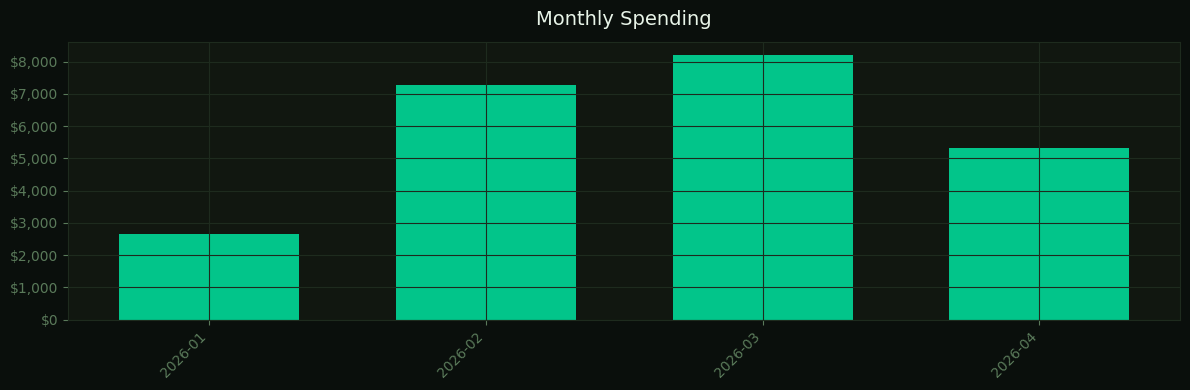

Average monthly spend: $5,864.22
Highest month: 2026-03 ($8,212.87)
Lowest month:  2026-01 ($2,648.91)


In [4]:
monthly = df.groupby("month")["amount"].sum().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly.index.astype(str), monthly.values, color="#00e5a0", alpha=0.85, width=0.65)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Monthly Spending", color="#e8f4e8", fontsize=14, pad=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(f"Average monthly spend: ${monthly.mean():,.2f}")
print(f"Highest month: {monthly.idxmax()} (${monthly.max():,.2f})")
print(f"Lowest month:  {monthly.idxmin()} (${monthly.min():,.2f})")

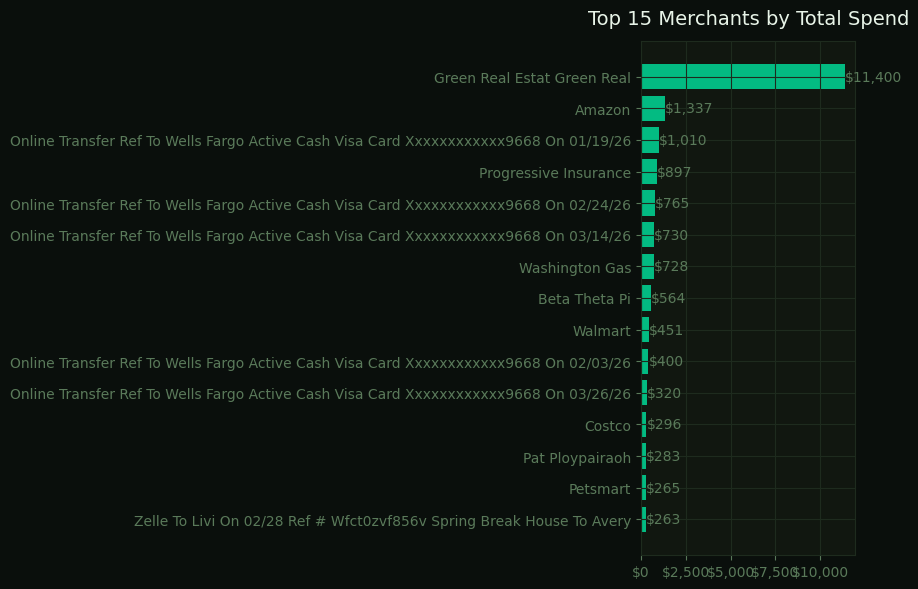

In [5]:
top_merchants = (
    df.groupby("clean_name")["amount"]
    .sum()
    .sort_values(ascending=True)
    .tail(15)
)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_merchants.index, top_merchants.values, color="#00e5a0", alpha=0.8)
for bar, val in zip(bars, top_merchants.values):
    ax.text(val + 10, bar.get_y() + bar.get_height() / 2,
            f"${val:,.0f}", va="center", color="#5a7a5a", fontsize=10)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Top 15 Merchants by Total Spend", color="#e8f4e8", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

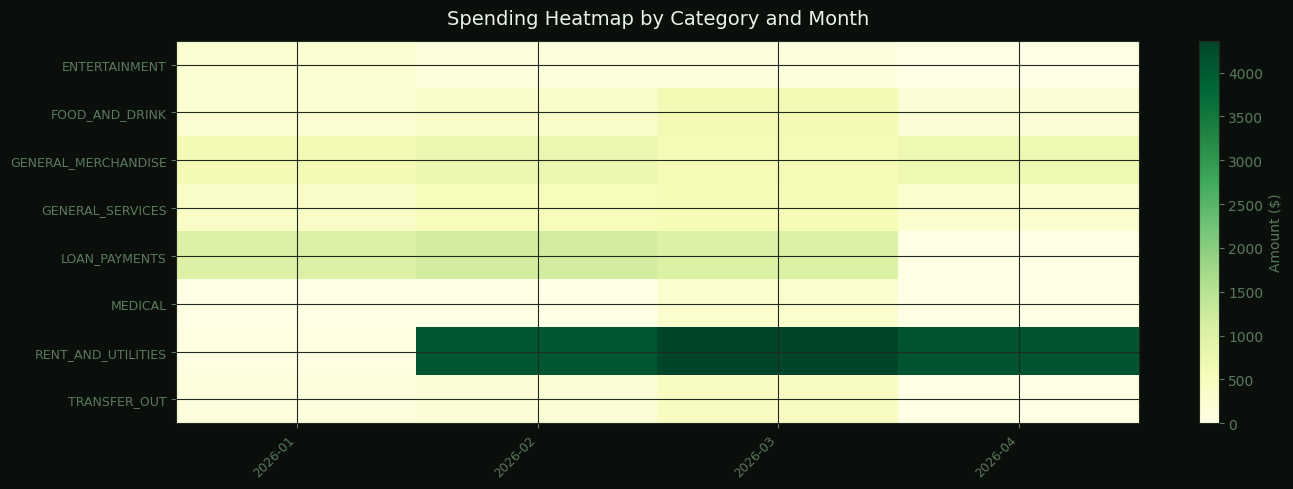

In [6]:
pivot = df.pivot_table(
    index="category_primary", columns="month",
    values="amount", aggfunc="sum", fill_value=0
)
top_cats = df.groupby("category_primary")["amount"].sum().nlargest(8).index
pivot = pivot.loc[pivot.index.isin(top_cats)]

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlGn")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([str(c) for c in pivot.columns], rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
ax.set_title("Spending Heatmap by Category and Month", color="#e8f4e8", fontsize=14, pad=12)
plt.colorbar(im, ax=ax, label="Amount ($)")
plt.tight_layout()
plt.show()

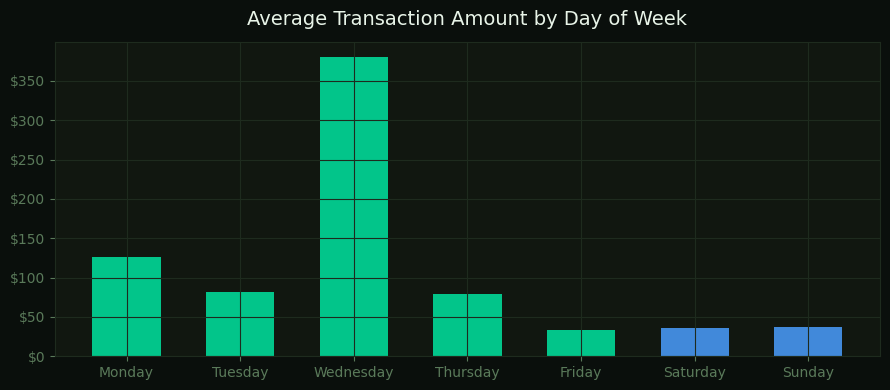

Weekday avg: $ 131.98
Weekend avg: $ 36.01


In [7]:
df["dow"] = df["date"].dt.day_name()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

dow_avg = df.groupby("dow")["amount"].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#4a9eff" if d in ("Saturday","Sunday") else "#00e5a0" for d in dow_order]
ax.bar(dow_avg.index, dow_avg.values, color=colors, alpha=0.85, width=0.6)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title("Average Transaction Amount by Day of Week", color="#e8f4e8", fontsize=14, pad=12)
plt.tight_layout()
plt.show()

print("Weekday avg: $", round(df[~df.dow.isin(["Saturday","Sunday"])]["amount"].mean(), 2))
print("Weekend avg: $", round(df[ df.dow.isin(["Saturday","Sunday"])]["amount"].mean(), 2))